# Train U-Tikhonov

This notebook trains the learned spatially weighted quadratic model through
the same shared SeaTurtle pipeline as U-TV and U-TGV. The scalar-baseline
summary from notebook 02 supplies the reference lambda and recommended fixed
CG depth.

## Project root discovery and Imports

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
from argparse import Namespace

import matplotlib.pyplot as plt
import pandas as pd
import torch

from scripts.train_u_tikhonov import (
    calibrated_map_scale,
    load_reference_lambda,
    train_u_tikhonov,
)
from src.training.denoising import build_seaturtle_loaders, get_device

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Scalar-reference and data validation
This cell validates the SeaTurtleID data and scalar-baseline files, loads the calibrated reference lambda and recommended CG depth, and derives the learned-map scale and bounds.

In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()
SCALAR_SUMMARY_PATH = (
    PROJECT_ROOT / "results" / "tikhonov" / "scalar_tikhonov_baseline_summary.csv"
)

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )
if not SCALAR_SUMMARY_PATH.is_file():
    raise FileNotFoundError(
        f"Missing scalar baseline: {SCALAR_SUMMARY_PATH}. Run notebook 02 first."
    )

scalar_summary = pd.read_csv(SCALAR_SUMMARY_PATH)
reference_lambda = load_reference_lambda(SCALAR_SUMMARY_PATH)
recommended_cg_iters = int(
    scalar_summary.iloc[0].get("recommended_fixed_cg_iters", 32)
)
initial_map_scale = calibrated_map_scale(reference_lambda)

print("Reference scalar lambda:", reference_lambda)
print("Recommended fixed CG iterations:", recommended_cg_iters)
print("Calibrated map scale:", initial_map_scale)


Reference scalar lambda: 2.080083823051904
Recommended fixed CG iterations: 32
Calibrated map scale: 3.000926616150338


## Experiment configuration 
This cell collects the dataset, architecture, solver, optimisation, noise, seed, and output settings into the namespace consumed by the training pipeline.

In [4]:
RUN_NAME = (
    f"u_tikhonov_bounded_cg{recommended_cg_iters}"
)

args = Namespace(
    data_root=str(SEA_TURTLE_ROOT),
    checkpoint_dir=str(
        PROJECT_ROOT
        / "checkpoints"
        / RUN_NAME
    ),

    image_size=256,
    max_images=550,
    val_images=50,

    sigma_min=0.0,
    sigma_max=0.2,
    val_sigma=0.1,
    val_noise_seed=10_000,

    base_channels=32,
    depth=3,

    cg_iters=int(recommended_cg_iters),
    cg_relative_tol=1e-7,

    reference_lambda=float(reference_lambda),
    scalar_baseline_summary=str(SCALAR_SUMMARY_PATH),

    # Used only by scaled_softplus checkpoints.
    # The training function resolves this to reference_lambda / log(2).
    map_scale=None,

    lambda_parameterization="bounded_sigmoid",
    lambda_min=1e-4,
    lambda_max=4.0 * float(reference_lambda),

    epochs=20,
    batch_size=1,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,

    num_workers=0,
    print_every=50,
    seed=42,
    device=None,
    clamp_for_metrics=True,
)

train_loader, val_loader = build_seaturtle_loaders(args)
print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))


Training images: 500
Validation images: 50


## Train U-Tikhonov


In [5]:
model_tikhonov, history_tikhonov = train_u_tikhonov(
    args,
    train_loader=train_loader,
    val_loader=val_loader,
)
display(history_tikhonov.tail())


Using device: mps
Model: u_tikhonov | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.958146e-03
Epoch 001 | batch 0100/0500 | train MSE 6.429667e-04
Epoch 001 | batch 0150/0500 | train MSE 1.453140e-04
Epoch 001 | batch 0200/0500 | train MSE 1.731046e-03
Epoch 001 | batch 0250/0500 | train MSE 2.396745e-03
Epoch 001 | batch 0300/0500 | train MSE 1.392433e-03
Epoch 001 | batch 0350/0500 | train MSE 2.201987e-03
Epoch 001 | batch 0400/0500 | train MSE 1.104670e-03
Epoch 001 | batch 0450/0500 | train MSE 1.374099e-03
Epoch 001 | batch 0500/0500 | train MSE 3.291678e-03
Epoch 001 | train MSE 1.229494e-03 | val MSE 1.133074e-03 | val PSNR 29.970 | val SSIM 0.7949 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.362820e-03
Epoch 002 | batch 0100/0500 | train MSE 8.029952e-04
Epoch 002 | batch 0150/0500 | train MSE 1.170977e-03
Epoch 002 | batch 0200/0500 | train MSE 1.338812e-03
Epoch 002 | batch 0250/0500 | train MSE 4.325206e-0

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99,val_lambda_lower_saturation_fraction,val_lambda_upper_saturation_fraction
15,16,0.000740,0.000827,31.298162,0.845173,0.009698,20.136563,0.322267,86.854654,5.239060,...,9.543697,5.553069,2.459859,0.014427,8.320335,0.810294,6.119549,8.318801,0.000699,0.403813
16,17,0.000773,0.000804,31.410026,0.855581,0.009698,20.136563,0.322267,86.916620,5.167696,...,9.675492,4.988518,2.766900,0.012379,8.320335,0.498992,5.038462,8.320126,0.000668,0.353739
17,18,0.000782,0.000787,31.504165,0.856420,0.009698,20.136563,0.322267,87.739636,5.255907,...,9.513105,5.531661,2.707263,0.019830,8.320335,0.576184,6.148306,8.320335,0.000460,0.436767
18,19,0.000752,0.000788,31.497169,0.856708,0.009698,20.136563,0.322267,78.639027,4.619229,...,10.824317,5.536443,2.790563,0.019564,8.320335,0.556219,6.259170,8.320335,0.000287,0.456439
19,20,0.000796,0.000802,31.443589,0.850768,0.009698,20.136563,0.322267,75.888102,4.992038,...,10.015949,6.115006,2.427903,0.018754,8.320335,0.875676,7.027733,8.320335,0.000165,0.479781


## Inspect training history

### U-Tikhonov training curves

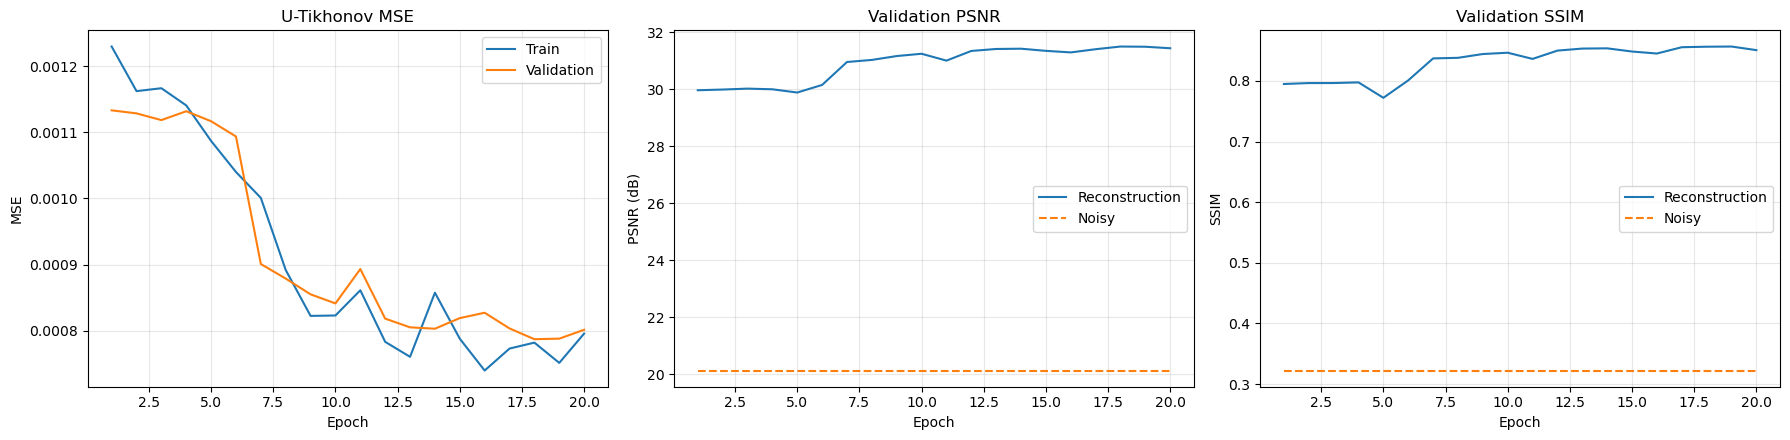

,epoch,val_lambda_mean,val_lambda_min,val_lambda_max
15,16,5.553069,0.014427,8.320335
16,17,4.988518,0.012379,8.320335
17,18,5.531661,0.019830,8.320335
18,19,5.536443,0.019564,8.320335
19,20,6.115006,0.018754,8.320335


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_bounded_cg32_curves.png


In [6]:
history_path = Path(args.checkpoint_dir) / "history.csv"
history_tikhonov = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(history_tikhonov["epoch"], history_tikhonov["train_mse"], label="Train")
axes[0].plot(history_tikhonov["epoch"], history_tikhonov["val_mse"], label="Validation")
axes[0].set(title="U-Tikhonov MSE", xlabel="Epoch", ylabel="MSE")

axes[1].plot(history_tikhonov["epoch"], history_tikhonov["val_psnr"], label="Reconstruction")
axes[1].plot(history_tikhonov["epoch"], history_tikhonov["noisy_psnr"], "--", label="Noisy")
axes[1].set(title="Validation PSNR", xlabel="Epoch", ylabel="PSNR (dB)")

axes[2].plot(history_tikhonov["epoch"], history_tikhonov["val_ssim"], label="Reconstruction")
axes[2].plot(history_tikhonov["epoch"], history_tikhonov["noisy_ssim"], "--", label="Noisy")
axes[2].set(title="Validation SSIM", xlabel="Epoch", ylabel="SSIM")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "results"
    / "training"
    / f"{RUN_NAME}_curves.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

lambda_columns = [
    column for column in history_tikhonov.columns
    if column in ("val_lambda_mean", "val_lambda_min", "val_lambda_max")
]
if lambda_columns:
    display(history_tikhonov[["epoch", *lambda_columns]].tail())
print("Saved:", figure_path)


### U-Tikhonov validation and lambda trends

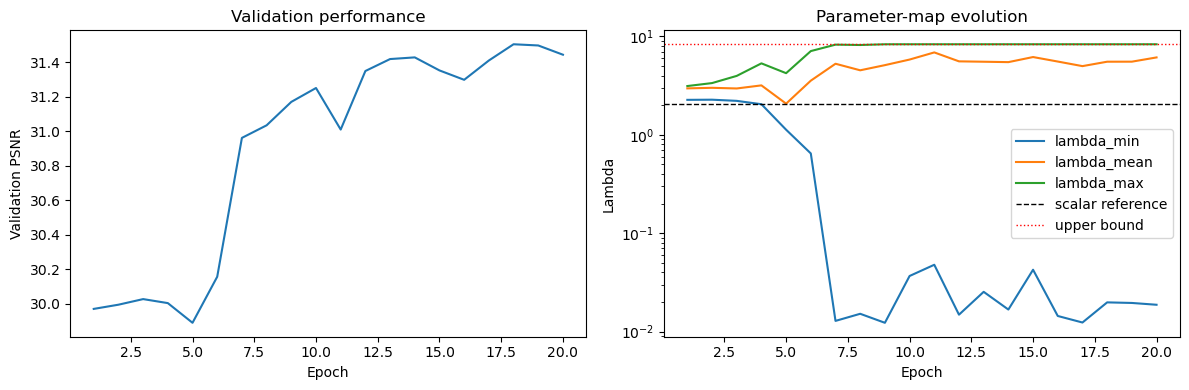

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_bounded_cg32_parameter_evolution.png


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_tikhonov["epoch"],
    history_tikhonov["val_psnr"],
)
axes[0].set(
    xlabel="Epoch",
    ylabel="Validation PSNR",
    title="Validation performance",
)

for column in [
    "val_lambda_min",
    "val_lambda_mean",
    "val_lambda_max",
]:
    axes[1].plot(
        history_tikhonov["epoch"],
        history_tikhonov[column],
        label=column.replace("val_", ""),
    )

axes[1].axhline(
    reference_lambda,
    color="black",
    linestyle="--",
    linewidth=1,
    label="scalar reference",
)
axes[1].axhline(
    args.lambda_max,
    color="red",
    linestyle=":",
    linewidth=1,
    label="upper bound",
)
axes[1].set(
    xlabel="Epoch",
    ylabel="Lambda",
    title="Parameter-map evolution",
)
axes[1].set_yscale("log")
axes[1].legend()
plt.tight_layout()
diagnostic_figure_path = (
    PROJECT_ROOT
    / "results"
    / "training"
    / f"{RUN_NAME}_parameter_evolution.png"
)

fig.savefig(
    diagnostic_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("Saved:", diagnostic_figure_path)
plt.show()